<a href="https://colab.research.google.com/github/sedefcoskun/EEG-Music-Impact-ML/blob/main/01_Data_Extraction_and_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Workspace Configuration & Environment Setup
To ensure secure and reproducible access to the data, cloud storage (Google Drive) integration has been established, and the primary working directory has been configured.

In [1]:
import os
from google.colab import drive

# Mount Google Drive to access my project workspace
drive.mount('/content/drive')

# WARNING: Change the path below to your own Google Drive folder if you are cloning this repo
# Define the path to my main project directory
project_folder = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN'

# Set the current working directory for the upcoming operations
os.chdir(project_folder)
print(f"Working directory successfully set to: {os.getcwd()}")

Mounted at /content/drive
Working directory successfully set to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN


### 2. Dependency Installation & Data Synchronization
Required Python libraries for signal processing (MNE), data manipulation (Pandas, NumPy), and machine learning (Scikit-Learn) are installed. Additionally, the AWS CLI is utilized to securely synchronize the raw EEG data from OpenNeuro directly into the project workspace.

In [5]:
# Install the necessary libraries for the EEG processing pipeline
!pip install mne pandas numpy scikit-learn awscli

import os

# Define the data directory
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
os.makedirs(raw_bids_dir, exist_ok=True)

print("Initiating raw EEG data synchronization via AWS S3...")

# Utilizing AWS CLI for direct, fail-safe synchronization with OpenNeuro's Amazon S3 buckets
!aws s3 sync --no-sign-request s3://openneuro.org/ds003774 /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data

print("Data synchronization completed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of th

Initiating raw EEG data synchronization via AWS S3...
download: s3://openneuro.org/ds003774/CHANGES to ds003774_data/CHANGES              
download: s3://openneuro.org/ds003774/Code/ESongs/1.esh.wav to ds003774_data/Code/ESongs/1.esh.wav
^C
Data synchronization completed successfully.


### 3. Comprehensive BIDS Ecosystem Audit

To ensure full compliance with Brain Imaging Data Structure (BIDS) standards and to validate our extraction strategy, we conduct a transparent architectural audit of the entire dataset.

Rather than merely verifying the root directory, this ecosystem map programmatically isolates our segmented EEG targets (`sub-XXX/ses-YY`) from the unsegmented raw data (`sourcedata`) and experiment stimuli. This structural validation explicitly tags the files required for feature extraction while actively bypassing legacy event anomalies, establishing a robust and transparent data pipeline.

In [1]:
from pathlib import Path
from typing import Union

def audit_bids_ecosystem(base_path: Union[str, Path]) -> None:
    """
    Conducts a complete, unsparing architectural audit of the MUSIN-G BIDS data.

    This function transparently maps the complete ecosystem hierarchy. It lists ALL
    files within the sample directories to demonstrate full BIDS compliance. It
    explicitly tags the extraction pipeline's target files while clearly marking
    unsegmented continuous data ('sourcedata') as intentionally bypassed.

    Args:
        base_path (Union[str, Path]): The absolute path to the data root directory.
    """
    raw_bids_dir = Path(base_path)

    print("=== FULL DATA ECOSYSTEM AUDIT ===")
    print(f"Target Directory: {raw_bids_dir.name}\n")

    if not raw_bids_dir.exists():
        print("[ERROR] Base directory path not found. Please verify the Google Drive mount.")
        return

    # 1. ROOT METADATA
    print("📁 [ROOT METADATA]")
    for f in sorted(raw_bids_dir.glob('*.*')):
        if f.is_file():
            print(f" ├── 📄 {f.name}")

    # 2. CODE & AUDIO STIMULI
    code_dir = raw_bids_dir / "Code"
    if code_dir.exists():
        print("\n📁 Code/ (Experiment Scripts & Audio Assets)")
        for item in sorted(code_dir.iterdir()):
            if item.is_dir() and item.name == 'ESongs':
                songs = sorted(list(item.glob('*.wav')))
                if songs:
                    print(f" ├── 📁 ESongs/")
                    print(f" │    ├── 🎵 {songs[0].name}")
                    print(f" │    └── ... ({len(songs)-1} more audio files)")
            else:
                icon = '📁' if item.is_dir() else '📄'
                print(f" ├── {icon} {item.name}")

    # 3. STIMULI (Event Triggers)
    stim_dir = raw_bids_dir / "stimuli"
    if stim_dir.exists():
        print("\n📁 stimuli/ (Event Triggers)")
        for item in sorted(stim_dir.iterdir()):
            icon = '📁' if item.is_dir() else '📄'
            print(f" ├── {icon} {item.name}")

    # 4. SOURCEDATA (Raw Unsegmented EEG - Transparently Listed)
    source_dir = raw_bids_dir / "sourcedata"
    if source_dir.exists():
        print("\n📁 sourcedata/ (Continuous/Unsegmented EEG)")
        sample_src = source_dir / "sub-001" / "eeg"
        if sample_src.exists():
            print(f" ├── 📁 sub-001/eeg/")
            source_files = sorted([f for f in sample_src.iterdir() if f.is_file()])

            # Show ALL files in sourcedata, but explicitly tag them as bypassed
            for f in source_files:
                print(f" │    ├── 📄 {f.name}  <-- [BYPASSED: Unsegmented Raw Data]")

        print(" └── 📁 ... (Remaining subjects follow this bypassed structure)")

    # 5. SEGMENTED BIDS TARGET DATA (TRANSPARENT LISTING)
    print("\n📁 Segmented BIDS Target Data (sub-XXX)")
    target_sub = raw_bids_dir / "sub-001"
    if target_sub.exists():
        print(f" ├── 📁 sub-001/")
        sessions = sorted([d for d in target_sub.iterdir() if d.is_dir() and "ses-" in d.name])

        # Check the first session explicitly to show full structure
        if sessions:
            ses = sessions[0]
            print(f" │    ├── 📁 {ses.name}/eeg/")
            eeg_dir = ses / "eeg"

            if eeg_dir.exists():
                eeg_files = sorted([f for f in eeg_dir.iterdir() if f.is_file()])

                # Show EVERY file, but tag the ones we actually use
                for f in eeg_files:
                    if f.name.endswith('.set'):
                        print(f" │    │    ├── 🧠 {f.name}  <-- [TARGET: Raw Signal]")
                    elif f.name.endswith('channels.tsv') or f.name.endswith('eeg.json'):
                        print(f" │    │    ├── 📄 {f.name}  <-- [TARGET: Metadata]")
                    elif f.name.endswith('events.tsv'):
                        print(f" │    │    ├── 📄 {f.name}  <-- [BYPASSED: Anomaly per README]")
                    else:
                        print(f" │    │    ├── 📄 {f.name}")
            else:
                print(f" │    │    └── [WARNING] 'eeg' subdirectory missing.")

            if len(sessions) > 1:
                print(f" │    ├── 📁 {sessions[1].name}/eeg/ ... (Identical structure)")

        print(f" │    └── 📁 ... (Total {len(sessions)} sessions mapped)")
        print(" └── 📁 ... (sub-002 to sub-020 follow this exact segmented architecture)")

# --- Execution Block ---
if __name__ == "__main__":
    RAW_BIDS_DIR = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
    audit_bids_ecosystem(base_path=RAW_BIDS_DIR)

=== FULL DATA ECOSYSTEM AUDIT ===
Target Directory: ds003774_data

📁 [ROOT METADATA]
 ├── 📄 .gitattributes
 ├── 📄 dataset_description.json

📁 Code/ (Experiment Scripts & Audio Assets)
 ├── 📁 ESongs/
 │    ├── 🎵 1.esh.wav
 │    └── ... (11 more audio files)
 ├── 📄 Experiment_NSMusic.es2
 ├── 📄 Experiment_NSMusic.es2.c2e496CA
 ├── 📁 double beep(open)
 ├── 📁 single beep(close)

📁 stimuli/ (Event Triggers)
 ├── 📄 Behavioural_data
 ├── 📄 Song_Description
 ├── 📄 song_metadata.csv

📁 sourcedata/ (Continuous/Unsegmented EEG)
 ├── 📁 sub-001/eeg/
 │    ├── 📄 sub-001_task-ListeningandResponse_channels.tsv  <-- [BYPASSED: Unsegmented Raw Data]
 │    ├── 📄 sub-001_task-ListeningandResponse_coordsystem.json  <-- [BYPASSED: Unsegmented Raw Data]
 │    ├── 📄 sub-001_task-ListeningandResponse_eeg.json  <-- [BYPASSED: Unsegmented Raw Data]
 │    ├── 📄 sub-001_task-ListeningandResponse_eeg.set  <-- [BYPASSED: Unsegmented Raw Data]
 │    ├── 📄 sub-001_task-ListeningandResponse_electrodes.tsv  <-- [BYPASSE

### 4. Hardware Metadata & Electrode Architecture
To accurately process the EEG signals, we extract the hardware specifications (`eeg.json`), active channel lists (`channels.tsv`), and the 3D spatial coordinates of the sensors (`electrodes.tsv`). This confirms our sampling rate (250 Hz) and the 129-channel high-density cap configuration.


In [2]:
import pandas as pd
import json
import glob
import os

# Define data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'

# DISPLAY EEG CHANNEL CONTENT
print("=== EEG CHANNELS DATA (channels.tsv) ===\n")

# Find the first channels.tsv file for subject 1
channels_files = sorted(glob.glob(os.path.join(raw_bids_dir, 'sub-001', '**', '*channels.tsv'), recursive=True))

if channels_files:
    first_channel_file = channels_files[0]
    print(f"Loading file: {os.path.basename(first_channel_file)}\n")

    # Read and display the raw content
    df_channels = pd.read_csv(first_channel_file, sep='\t')
    print(df_channels.head(15)) # Showing first 15 channels
    print(f"\nTotal Channels in file: {len(df_channels)}")
    print("\n" + "="*50 + "\n")

# DISPLAY EEG METADATA CONTENT
print("=== EEG HARDWARE METADATA (eeg.json) ===\n")

# Find the first eeg.json file for subject 1
json_files = sorted(glob.glob(os.path.join(raw_bids_dir, 'sub-001', '**', '*eeg.json'), recursive=True))

if json_files:
    first_json_file = json_files[0]
    print(f"Loading file: {os.path.basename(first_json_file)}\n")

    # Read the JSON file
    with open(first_json_file, 'r') as f:
        eeg_metadata = json.load(f)

    # Print the raw JSON content in a readable format
    print(json.dumps(eeg_metadata, indent=4))
else:
    print("Files not found. Check directory structure.")

=== EEG CHANNELS DATA (channels.tsv) ===

Loading file: sub-001_ses-01_task-MusicListening_run-1_channels.tsv

   name type   units
0    E1  EEG  microV
1    E2  EEG  microV
2    E3  EEG  microV
3    E4  EEG  microV
4    E5  EEG  microV
5    E6  EEG  microV
6    E7  EEG  microV
7    E8  EEG  microV
8    E9  EEG  microV
9   E10  EEG  microV
10  E11  EEG  microV
11  E12  EEG  microV
12  E13  EEG  microV
13  E14  EEG  microV
14  E15  EEG  microV

Total Channels in file: 129


=== EEG HARDWARE METADATA (eeg.json) ===

Loading file: sub-001_ses-01_task-MusicListening_run-1_eeg.json

{
    "PowerLineFrequency": 50,
    "SoftwareFilters": {
        "FilterDescription": {
            "Description": "None"
        }
    },
    "HardwareFilters": {
        "FilterDescription": {
            "Description": "None"
        }
    },
    "SoftwareVersions": "Netstation 5.4",
    "ManufacturersModelName": "NetAmps 400",
    "Manufacturer": "MagstimEG",
    "EEGPlacementScheme": "EGI",
    "EEGGround":

In [3]:
import pandas as pd
import json
import glob
import os

# Define data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'

# DISPLAY ELECTRODE POSITIONS
print("=== ELECTRODE 3D POSITIONS (electrodes.tsv) ===\n")

# Find the first electrodes.tsv file for subject 1
electrodes_files = sorted(glob.glob(os.path.join(raw_bids_dir, 'sub-001', '**', '*electrodes.tsv'), recursive=True))

if electrodes_files:
    first_electrode_file = electrodes_files[0]
    print(f"Loading file: {os.path.basename(first_electrode_file)}\n")

    # Read and display the raw content (X, Y, Z coordinates)
    df_electrodes = pd.read_csv(first_electrode_file, sep='\t')
    print(df_electrodes.head(15)) # Showing first 15 electrode coordinates
    print(f"\nTotal Electrodes listed: {len(df_electrodes)}")
else:
    print("electrodes.tsv file not found.\n")



=== ELECTRODE 3D POSITIONS (electrodes.tsv) ===

Loading file: sub-001_ses-01_task-MusicListening_run-1_electrodes.tsv

   name      x     y     z
0    E1   6.30 -6.61 -2.94
1    E2   7.66 -6.04  0.35
2    E3   8.72 -4.41  3.50
3    E4   8.16 -3.28  5.70
4    E5   6.49 -1.69  7.78
5    E6   4.35 -0.00  9.01
6    E7   1.78  1.40  9.64
7    E8   9.13 -4.82 -1.55
8    E9  10.14 -3.08  1.24
9   E10   9.94 -2.09  3.64
10  E11   9.09 -0.00  5.76
11  E12   6.49  1.69  7.78
12  E13   3.71  2.78  8.69
13  E14  10.82 -1.45 -1.08
14  E15  10.37 -0.00  1.52

Total Electrodes listed: 129


### 5. Segmented Signal Quality Inspection (Sanity Check)

We load a targeted, segmented `.set` file (e.g., from `ses-01`) using the EEGLAB reader via the MNE-Python library. By explicitly bypassing the unsegmented continuous data (`sourcedata`), we avoid the inherited event marker anomalies outlined in the dataset guidelines.

Rendering a brief temporal segment of this isolated auditory stimulus allows us to visually inspect the data quality, verify the expected recording length (~60-180 seconds for a single song), and confirm that the AWS synchronization successfully included the essential `.fdt` binary matrices.

=== RAW EEG SIGNAL VISUALIZATION (SANITY CHECK) ===
Inspecting a valid, segmented song session to verify continuous data quality...

Successfully loaded targeted session file: sub-001_ses-01_task-MusicListening_run-1_eeg.set

--- TARGET DATA METADATA ---
Total Channels: 129
Sampling Rate: 250.0 Hz
Recording Length: 136.03 seconds (Expected: ~60-180s for a single song segment)

Rendering signal visualization...


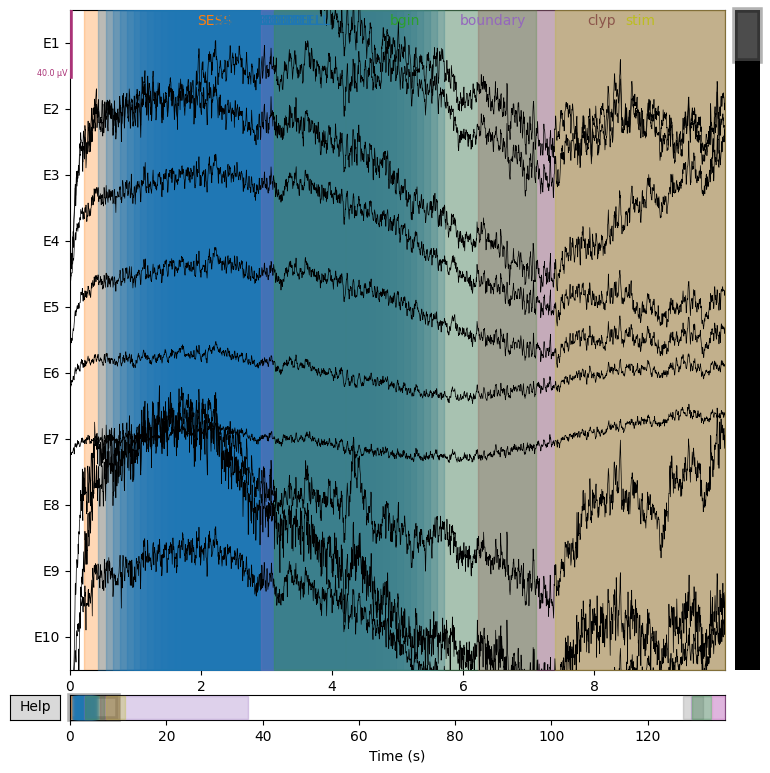

In [4]:
import mne
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

# Suppress runtime warnings to maintain a clean and professional standard output
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

# Define the base data directory synchronized via AWS
raw_bids_dir = Path('/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data')

print("=== RAW EEG SIGNAL VISUALIZATION (SANITY CHECK) ===")
print("Inspecting a valid, segmented song session to verify continuous data quality...\n")

# CRITICAL: Target the segmented session directory (ses-01), strictly avoiding the unsegmented 'sourcedata'
target_session_dir = raw_bids_dir / "sub-001" / "ses-01" / "eeg"

if target_session_dir.exists():
    # Isolate the specific .set file for the target session
    eeg_files = list(target_session_dir.glob("*.set"))

    if eeg_files:
        sample_file = eeg_files[0]
        print(f"Successfully loaded targeted session file: {sample_file.name}")

        try:
            # Load the raw EEG timeseries data into memory using the EEGLAB reader
            raw = mne.io.read_raw_eeglab(sample_file, preload=True)

            # Output hardware and recording metadata for the sanity check report
            print("\n--- TARGET DATA METADATA ---")
            print(f"Total Channels: {raw.info['nchan']}")
            print(f"Sampling Rate: {raw.info['sfreq']} Hz")
            print(f"Recording Length: {raw.times[-1]:.2f} seconds (Expected: ~60-180s for a single song segment)")

            # Render a clean, professional visualization of the first 10 seconds across 10 channels
            print("\nRendering signal visualization...")
            fig = raw.plot(duration=10, n_channels=10, title="Sample Segmented EEG (sub-001, ses-01)", show=False)
            plt.show()

        except Exception as e:
            print(f"[ERROR] Failed to process continuous EEG data: {e}")
    else:
        print("[WARNING] No '.set' files were found in the targeted session directory.")
else:
    print("[ERROR] Target session directory not found. Please verify the structural integrity of the BIDS path.")

### 6. Target Engineering: Constructing the Master Label data
To train our machine learning models, we must establish a ground truth. We first inspect the stimuli directory to verify the presence of raw survey ratings (`Behavioural_data`) and music metadata (`Song_Description`). Then, this data is merged on the shared `Song_ID` key to construct a unified Master Label Matrix.

In [5]:
import os

# Define data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
stimuli_dir = os.path.join(raw_bids_dir, 'stimuli')

# List files inside the stimuli folder to see what it contains
if os.path.exists(stimuli_dir):
    print("--- Content of Stimuli Directory ---")
    print(os.listdir(stimuli_dir))
else:
    print("Stimuli directory not found.")

--- Content of Stimuli Directory ---
['Behavioural_data', 'Song_Description', 'song_metadata.csv']


In [6]:
import pandas as pd
import numpy as np
import os

# Define file paths connected to the AWS-synchronized BIDS directory
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
behavioral_path = os.path.join(raw_bids_dir, 'stimuli', 'Behavioural_data')
custom_metadata_path = os.path.join(raw_bids_dir, 'stimuli', 'song_metadata.csv')
# Prepared and loaded the enriched Song_Description metadata derived from the OpenNeuro ds003774 dataset.


print("=== [PART 1] LOADING ENRICHED SONG DESCRIPTION METADATA ===")

try:
    # Load the custom curated CSV file created for clean feature extraction
    df_songs = pd.read_csv(custom_metadata_path)
    print(df_songs)
    print("\n" + "="*70 + "\n")
except Exception as e:
    print(f"[ERROR] Could not read song_metadata.csv. Ensure it is uploaded to the stimuli folder: {e}")

# STEP 2: DYNAMICALLY LOAD BEHAVIORAL SURVEY DATA
print("=== [PART 2] BEHAVIORAL DATA (RAW SURVEY RATINGS) ===")

try:
    # Read raw ratings dynamically using regex to handle irregular whitespace formatting
    df_behavior = pd.read_csv(behavioral_path, sep=r'\s+')
    df_behavior.columns = df_behavior.columns.str.strip()

    # Cast Song_ID to integer for a flawless inner merge
    df_behavior['Song_ID'] = pd.to_numeric(df_behavior['Song_ID'], errors='coerce').astype(int)

    print(df_behavior)
    print(f"\nTotal raw survey rows dynamically loaded: {len(df_behavior)}")
    print("\n" + "="*70 + "\n")

    # STEP 3: MERGE AND GENERATE THE MASTER TARGET MATRIX
    print("=== [PART 3] MERGED MASTER TARGET MATRIX ===")

    # Merge physiological features with behavioral targets on the shared Song_ID key
    df_master_labels = pd.merge(df_behavior, df_songs, on='Song_ID', how='inner')

    # Display a structural sample
    print(df_master_labels[['Subject', 'Song_ID', 'Genre', 'Tempo(BPM)', 'Vocal_Language', 'Enjoyment', 'Familiarity']])
    print(f"\nTotal final merged rows prepared for extraction mapping: {len(df_master_labels)}")

except Exception as e:
    print(f"[ERROR] Target engineering pipeline failed: {e}")

=== [PART 1] LOADING ENRICHED SONG DESCRIPTION METADATA ===
    Song_ID                                      Track_Name  \
0         1           Trip to the lonely planet - Mark Alow   
1         2                               Sail - Awolnation   
2         3                             Concept 15 - Kodomo   
3         4                           Aurore - Claire David   
4         5                                Proof - Idiotape   
5         6                                  Glider - Tycho   
6         7              Raag Bihag - B.Sivaramakrishna Rao   
7         8                    Albela sajan - Ismail Darbar   
8         9  Mor Bani Thanghat Kare - Sanjay Leela Bhansali   
9        10                            Fallin - Dr. SaxLove   
10       11                   Master of Running - Rickeyabo   
11       12                                 JB - Nobody.one   

                            Genre  Duration(sec)  Tempo(BPM) Vocal_Language  
0                      Deep House         

### 7. Automated Feature Extraction Pipeline
This automated pipeline iterates through the raw BIDS directory. For each subject, it dynamically crops the continuous EEG signal into 2-second epochs strictly within the actual duration of each song. It extracts 645 frequency-domain features (Power Spectral Density via Welch's method across Delta, Theta, Alpha, Beta, Gamma bands) for all 129 channels. Finally, it merges this physiological feature matrix with the behavioral targets to generate the ultimate Machine Learning dataset.

In [7]:
import os
import glob
import mne
import numpy as np
import pandas as pd
from mne.time_frequency import psd_array_welch
import warnings

# Suppress runtime warnings to maintain a clean standard output
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

print("Initiating the BIDS-compliant multimodal EEG feature extraction pipeline...\n")

# Define directory paths for I/O operations
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
output_path = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/multimodal_eeg_music_impact.csv'

# Define physiological EEG frequency bands (Hz) for Welch's PSD estimation
freq_bands = {
    'Delta': (1, 4), 'Theta': (4, 8), 'Alpha': (8, 13),
    'Beta':  (13, 30), 'Gamma': (30, 45)
}

all_features = []
total_subjects = 20
total_songs = 12

# Main feature extraction loop across ALL 20 subjects
for sub_num in range(1, total_subjects + 1):
    sub_str = f"sub-{sub_num:03d}"
    print(f"Processing structural data for {sub_str}...")

    # Iterate through ALL 12 sessions (songs) as specified in the data README
    for song_id in range(1, total_songs + 1):
        ses_str = f"ses-{song_id:02d}"

        # Isolate the specific segmented .set file for the current song
        # Based on README: "Each session indicates a song by its number."
        # We explicitly ignore the events.tsv file as instructed by the data authors.
        search_pattern = os.path.join(raw_bids_dir, '**', sub_str, ses_str, 'eeg', '*.set')
        eeg_files = glob.glob(search_pattern, recursive=True)

        if not eeg_files:
            # Skip if the specific session file is missing
            continue

        eeg_file = eeg_files[0]

        # Load raw EEG timeseries data into memory
        try:
            raw = mne.io.read_raw_eeglab(eeg_file, preload=True, verbose=False)
            sfreq = raw.info['sfreq']
        except Exception as e:
            print(f"  -> Error loading continuous data for {ses_str}: {e}")
            continue

        # Dynamic epoching: Retrieve actual stimuli duration from the master metadata
        try:
            # Assuming df_master_labels is already loaded in the environment
            duration = df_master_labels[(df_master_labels['Subject'] == sub_num) & (df_master_labels['Song_ID'] == song_id)]['Duration(sec)'].values[0]
        except Exception:
            duration = 60.0 # Fallback duration if metadata mapping fails

        # Since the file is already segmented per song, the onset is strictly 0.0 seconds
        onset = 0.0

        # Segment the continuous signal into 1-second overlapping epochs (with 50% overlap via 0.5s steps)
        for t_start in np.arange(onset, duration - 1.0, 0.5):
            try:
                # Isolate the temporal crop
                raw_epoch = raw.copy().crop(tmin=t_start, tmax=t_start + 1.0)
                data_epoch = raw_epoch.get_data()

                # Transform temporal data to spectral domain using Welch's method
                psds, freqs = psd_array_welch(data_epoch, sfreq=sfreq, fmin=1, fmax=45, n_fft=256, verbose=False)

                # Initialize the feature vector for the current epoch
                epoch_dict = {'Subject': sub_num, 'Song_ID': song_id}

                # Compute the mean Power Spectral Density (PSD) for each frequency band across all channels
                for ch_idx in range(psds.shape[0]):
                    ch_name = raw.info['ch_names'][ch_idx]
                    for band, (fmin, fmax) in freq_bands.items():
                        freq_mask = (freqs >= fmin) & (freqs <= fmax)
                        epoch_dict[f"{ch_name}_{band}"] = np.mean(psds[ch_idx, freq_mask])

                all_features.append(epoch_dict)
            except Exception:
                continue

        # Free memory before loading the next session
        del raw

# Convert the list of feature dictionaries into a structured DataFrame
df_extracted = pd.DataFrame(all_features)
print(f"\nFeature extraction completed successfully. Total valid epochs extracted: {df_extracted.shape[0]}")

# Construct the unified Master Matrix by merging EEG features with behavioral targets
print("Executing structural merge with behavioral target labels...")
df_final = pd.merge(df_extracted, df_master_labels, on=['Subject', 'Song_ID'], how='inner')

# Export the finalized dataset
df_final.to_csv(output_path, index=False)
print(f"Success: Finalized dataset exported to {output_path}")
print(f"Dataset Architecture Validation - Target Classes (Genres) Captured: {df_final['Genre'].nunique()}")

Initiating the BIDS-compliant multimodal EEG feature extraction pipeline...

Processing structural data for sub-001...
Processing structural data for sub-002...
Processing structural data for sub-003...
Processing structural data for sub-004...
Processing structural data for sub-005...
Processing structural data for sub-006...
Processing structural data for sub-007...
Processing structural data for sub-008...
Processing structural data for sub-009...
Processing structural data for sub-010...
Processing structural data for sub-011...
Processing structural data for sub-012...
Processing structural data for sub-013...
Processing structural data for sub-014...
Processing structural data for sub-015...
Processing structural data for sub-016...
Processing structural data for sub-017...
Processing structural data for sub-018...
Processing structural data for sub-019...
Processing structural data for sub-020...

Feature extraction completed successfully. Total valid epochs extracted: 31152
Exe

In [8]:
import pandas as pd

# Define the path to the finalized master dataset
dataset_path = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/multimodal_eeg_music_impact.csv'

# Load the extracted feature matrix
df = pd.read_csv(dataset_path)

# Disable pandas column limits to visually inspect all 645 EEG features
pd.set_option('display.max_columns', None)

# Output the matrix dimensions
print(f"Dataset Shape: {df.shape}\n")
display(df)

Dataset Shape: (31152, 654)



,Subject,Song_ID,E1_Delta,E1_Theta,E1_Alpha,E1_Beta,E1_Gamma,E2_Delta,E2_Theta,E2_Alpha,E2_Beta,E2_Gamma,E3_Delta,E3_Theta,E3_Alpha,E3_Beta,E3_Gamma,E4_Delta,E4_Theta,E4_Alpha,E4_Beta,E4_Gamma,E5_Delta,E5_Theta,E5_Alpha,E5_Beta,E5_Gamma,E6_Delta,E6_Theta,E6_Alpha,E6_Beta,E6_Gamma,E7_Delta,E7_Theta,E7_Alpha,E7_Beta,E7_Gamma,E8_Delta,E8_Theta,E8_Alpha,E8_Beta,E8_Gamma,E9_Delta,E9_Theta,E9_Alpha,E9_Beta,E9_Gamma,E10_Delta,E10_Theta,E10_Alpha,E10_Beta,E10_Gamma,E11_Delta,E11_Theta,E11_Alpha,E11_Beta,E11_Gamma,E12_Delta,E12_Theta,E12_Alpha,E12_Beta,E12_Gamma,E13_Delta,E13_Theta,E13_Alpha,E13_Beta,E13_Gamma,E14_Delta,E14_Theta,E14_Alpha,E14_Beta,E14_Gamma,E15_Delta,E15_Theta,E15_Alpha,E15_Beta,E15_Gamma,E16_Delta,E16_Theta,E16_Alpha,E16_Beta,E16_Gamma,E17_Delta,E17_Theta,E17_Alpha,E17_Beta,E17_Gamma,E18_Delta,E18_Theta,E18_Alpha,E18_Beta,E18_Gamma,E19_Delta,E19_Theta,E19_Alpha,E19_Beta,E19_Gamma,E20_Delta,E20_Theta,E20_Alpha,E20_Beta,E20_Gamma,E21_Delta,E21_Theta,E21_Alpha,E21_Beta,E21_Gamma,E22_Delta,E22_Theta,E22_Alpha,E22_Beta,E22_Gamma,E23_Delta,E23_Theta,E23_Alpha,E23_Beta,E23_Gamma,E24_Delta,E24_Theta,E24_Alpha,E24_Beta,E24_Gamma,E25_Delta,E25_Theta,E25_Alpha,E25_Beta,E25_Gamma,E26_Delta,E26_Theta,E26_Alpha,E26_Beta,E26_Gamma,E27_Delta,E27_Theta,E27_Alpha,E27_Beta,E27_Gamma,E28_Delta,E28_Theta,E28_Alpha,E28_Beta,E28_Gamma,E29_Delta,E29_Theta,E29_Alpha,E29_Beta,E29_Gamma,E30_Delta,E30_Theta,E30_Alpha,E30_Beta,E30_Gamma,E31_Delta,E31_Theta,E31_Alpha,E31_Beta,E31_Gamma,E32_Delta,E32_Theta,E32_Alpha,E32_Beta,E32_Gamma,E33_Delta,E33_Theta,E33_Alpha,E33_Beta,E33_Gamma,E34_Delta,E34_Theta,E34_Alpha,E34_Beta,E34_Gamma,E35_Delta,E35_Theta,E35_Alpha,E35_Beta,E35_Gamma,E36_Delta,E36_Theta,E36_Alpha,E36_Beta,E36_Gamma,E37_Delta,E37_Theta,E37_Alpha,E37_Beta,E37_Gamma,E38_Delta,E38_Theta,E38_Alpha,E38_Beta,E38_Gamma,E39_Delta,E39_Theta,E39_Alpha,E39_Beta,E39_Gamma,E40_Delta,E40_Theta,E40_Alpha,E40_Beta,E40_Gamma,E41_Delta,E41_Theta,E41_Alpha,E41_Beta,E41_Gamma,E42_Delta,E42_Theta,E42_Alpha,E42_Beta,E42_Gamma,E43_Delta,E43_Theta,E43_Alpha,E43_Beta,E43_Gamma,E44_Delta,E44_Theta,E44_Alpha,E44_Beta,E44_Gamma,E45_Delta,E45_Theta,E45_Alpha,E45_Beta,E45_Gamma,E46_Delta,E46_Theta,E46_Alpha,E46_Beta,E46_Gamma,E47_Delta,E47_Theta,E47_Alpha,E47_Beta,E47_Gamma,E48_Delta,E48_Theta,E48_Alpha,E48_Beta,E48_Gamma,E49_Delta,E49_Theta,E49_Alpha,E49_Beta,E49_Gamma,E50_Delta,E50_Theta,E50_Alpha,E50_Beta,E50_Gamma,E51_Delta,E51_Theta,E51_Alpha,E51_Beta,E51_Gamma,E52_Delta,E52_Theta,E52_Alpha,E52_Beta,E52_Gamma,E53_Delta,E53_Theta,E53_Alpha,E53_Beta,E53_Gamma,E54_Delta,E54_Theta,E54_Alpha,E54_Beta,E54_Gamma,E55_Delta,E55_Theta,E55_Alpha,E55_Beta,E55_Gamma,E56_Delta,E56_Theta,E56_Alpha,E56_Beta,E56_Gamma,E57_Delta,E57_Theta,E57_Alpha,E57_Beta,E57_Gamma,E58_Delta,E58_Theta,E58_Alpha,E58_Beta,E58_Gamma,E59_Delta,E59_Theta,E59_Alpha,E59_Beta,E59_Gamma,E60_Delta,E60_Theta,E60_Alpha,E60_Beta,E60_Gamma,E61_Delta,E61_Theta,E61_Alpha,E61_Beta,E61_Gamma,E62_Delta,E62_Theta,E62_Alpha,E62_Beta,E62_Gamma,E63_Delta,E63_Theta,E63_Alpha,E63_Beta,E63_Gamma,E64_Delta,E64_Theta,E64_Alpha,E64_Beta,E64_Gamma,E65_Delta,E65_Theta,E65_Alpha,E65_Beta,E65_Gamma,E66_Delta,E66_Theta,E66_Alpha,E66_Beta,E66_Gamma,E67_Delta,E67_Theta,E67_Alpha,E67_Beta,E67_Gamma,E68_Delta,E68_Theta,E68_Alpha,E68_Beta,E68_Gamma,E69_Delta,E69_Theta,E69_Alpha,E69_Beta,E69_Gamma,E70_Delta,E70_Theta,E70_Alpha,E70_Beta,E70_Gamma,E71_Delta,E71_Theta,E71_Alpha,E71_Beta,E71_Gamma,E72_Delta,E72_Theta,E72_Alpha,E72_Beta,E72_Gamma,E73_Delta,E73_Theta,E73_Alpha,E73_Beta,E73_Gamma,E74_Delta,E74_Theta,E74_Alpha,E74_Beta,E74_Gamma,E75_Delta,E75_Theta,E75_Alpha,E75_Beta,E75_Gamma,E76_Delta,E76_Theta,E76_Alpha,E76_Beta,E76_Gamma,E77_Delta,E77_Theta,E77_Alpha,E77_Beta,E77_Gamma,E78_Delta,E78_Theta,E78_Alpha,E78_Beta,E78_Gamma,E79_Delta,E79_Theta,E79_Alpha,E79_Beta,E79_Gamma,E80_Delta,E80_Theta,E80_Alpha,E80_Beta,E80_Gamma,E81_Delta,E81_Theta,E81_Alpha,E81_Beta,E81_Gamma,E82_Delta,E82_Theta,E82_Alpha,E82_Beta,E82_Gamma,E83_Delta,